# CYNAR: analyze your own trajectory data

A generic template notebook: point it at your own trajectory (a CSV/TXT/NPY file of positions,
optionally with a leading time column) and it estimates the entropy production rate
$\sigma=4\,\mathcal{T}+\mathcal{G}$, adapting to the data's own dimensionality. If `DATA_PATH`
below is left unset, it runs on a small synthetic 2D demo dataset so you can see the expected
output before pointing it at real data.

See `docs/considerations_on_CYNAR.tex` for the reasoning behind each knob (the $H$-sweep, the
cell-size sweep, smoothing) in more detail.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar import cfg, inflow
from cynar.data_io import load_trajectory
from cynar.plot import plot_trajectory, plot_field_rho

import common as C

np.set_printoptions(precision=4, suppress=True)

## Configuration -- set these before running anything below

In [2]:
# ---- Data source ----
# Quick-pick one of the bundled demo files (notebooks/DATA/README.md) by name below, or set
# EXAMPLE = None and fill in DATA_PATH/HAS_TIME_COLUMN/DT yourself for your own data.
EXAMPLES = {
    "linear2d_with_time":     dict(path="DATA/linear2d_with_time.csv.gz",     has_time_column=True,  dt=None),
    "linear2d_no_time":       dict(path="DATA/linear2d_no_time.csv.gz",       has_time_column=False, dt=2e-3),
    "linear2d_no_time_npy":   dict(path="DATA/linear2d_no_time.npy.gz",       has_time_column=False, dt=2e-3),
    "linear2d_jittered_time": dict(path="DATA/linear2d_jittered_time.csv.gz", has_time_column=True,  dt=None),
    "lorenz3d_with_time":     dict(path="DATA/lorenz3d_with_time.csv.gz",     has_time_column=True,  dt=None),
    "highdim6d_no_time":      dict(path="DATA/highdim6d_no_time.csv.gz",      has_time_column=False, dt=2e-3),
}

EXAMPLE = None  # set to one of the EXAMPLES keys above to try a bundled demo file; None -> synthetic fallback

if EXAMPLE is not None:
    ex = EXAMPLES[EXAMPLE]
    DATA_PATH, HAS_TIME_COLUMN, DT = ex["path"], ex["has_time_column"], ex["dt"]
else:
    DATA_PATH = None       # path to your .csv/.txt/.npy trajectory file; None -> synthetic demo dataset
    HAS_TIME_COLUMN = True  # True: column 0 of the file is time (dt is inferred from it)
                            # False: every column is a coordinate, and DT below is used directly
    DT = None               # only used if HAS_TIME_COLUMN is False; must be set in that case

# ---- Traffic (correlation-fit window) sweep ----
H_LIST = np.asarray((0.01,0.02,0.05,0.1,0.2,0.3,0.5))  # candidate fit-window widths to sweep for a stable Tr*
N_SLICE = 5                          # trajectory chunks used to judge stability across H

# ---- Inflow rate (grid) sweep ----
MAX_DIM_FOR_INFLOW = 4        # dimensions above this skip the grid/inflow step entirely
                              # (grid cost grows as ~bins_per_axis^d; see 04_lorenz96.ipynb)
N_TARGET_BINS_PER_DIM = 10   # controls the base cell size side0 proposed from the data's own spread
R_LIST = (1.0, 1.5, 2.0, 3.0, 4.0, 5.0)  # multipliers of side0 swept for cell-size stability
N_MIN = 2                     # minimum cell-neighbor count for a reliable score estimate
THR_G = 200.0                 # safety-net clip on any surviving score component
Q = None                      # smoothing bandwidth, as a multiple of cell size; None -> package default (0.5)
W_MIN = None                  # smoothing neighbor cutoff weight; None -> package default (exp(-3))

# ---- Reference (ground-truth) values ----
SHOW_TRUE_VALUES = True  # if a matching <data file>.truth.json exists (see notebooks/DATA/README.md),
                          # or the synthetic fallback is used, overlay its exact Tr/sigma/G on the plots

## Load data

With `DATA_PATH=None` (the default), a small synthetic Brownian-vortex trajectory is generated so
the rest of the notebook has something to run on. Set `DATA_PATH` to a real file to analyze your
own data instead. If a `<base name>.truth.json` file exists alongside it (with `Tr_true`,
`sigma_true`, `G_true` keys; `<base name>` strips every extension, e.g. `.csv.gz`), it is picked up
automatically and overlaid on the plots below when `SHOW_TRUE_VALUES=True`; real data won't have
one, so `true_values` simply stays `None`.

DATA_PATH is not set: generating a small synthetic 2D demo dataset so this notebook runs end-to-end. Set DATA_PATH above to analyze your own data.


Loaded trajectory: T=200000 points, d=2 dimensions, dt=0.002
Reference values: {'Tr_true': 0.9000000000000002, 'sigma_true': 4.800000000000001, 'G_true': 1.1999999999999997}


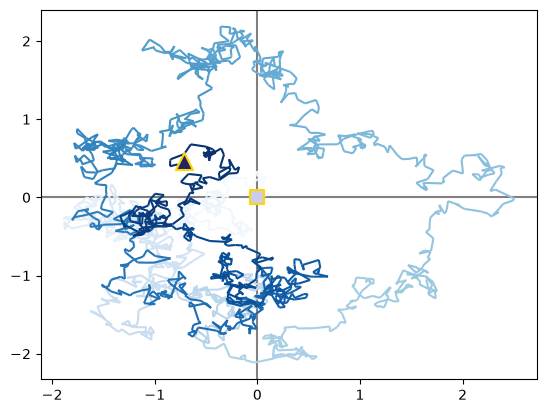

In [3]:
true_values = None

if DATA_PATH is None:
    print("DATA_PATH is not set: generating a small synthetic 2D demo dataset so this notebook "
          "runs end-to-end. Set DATA_PATH above to analyze your own data.")
    from cynar.simul.linear import simulate_linear_diffusion, theory_linear_general
    A_demo = np.array([[-0.2, -2.0], [0.4, -1.0]])
    D_demo = np.eye(2)
    dt = 2e-3
    X = simulate_linear_diffusion(200_000, A_demo, D_demo, dt, oversampling=10, method="euler", seed=0)
    if SHOW_TRUE_VALUES:
        Tr_true, sigma_true, G_true = theory_linear_general(A_demo, D_demo)
        true_values = dict(Tr_true=Tr_true, sigma_true=sigma_true, G_true=G_true)
else:
    X, dt = load_trajectory(DATA_PATH, HAS_TIME_COLUMN, dt=DT)
    # strip every suffix (.csv.gz, .npy.gz, ...) down to the base name, since
    # CSV/.npy/compressed variants of the same scenario share one truth file
    base = Path(DATA_PATH)
    while base.suffix:
        base = base.with_suffix("")
    truth_path = Path(str(base) + ".truth.json")
    if SHOW_TRUE_VALUES and truth_path.exists():
        with open(truth_path) as f:
            true_values = json.load(f)

T, d = X.shape
print(f"Loaded trajectory: T={T} points, d={d} dimensions, dt={dt:.6g}")
if true_values is not None:
    print(f"Reference values: {true_values}")

if d >= 2:
    plot_trajectory(X, i=0, j=1, tmin=0, tmax=min(2000, T))

## Traffic: correlation-fit window sweep

Sweeps `H_LIST` and picks the $H$ with the smallest across-chunk spread in the fitted traffic
$\mathcal{T}$, the same "stable-window" heuristic used in every example notebook.

H*=0.010  Tr*=0.6185 +/- 0.3023


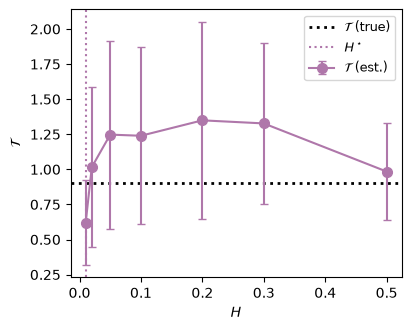

In [4]:
traffic_result = C.sweep_traffic_vs_H(X, dt, H_LIST, N_slice=N_SLICE)
tr_star = C.pick_stable_Tr(traffic_result)
print(f"H*={tr_star['H_star']:.3f}  Tr*={tr_star['Tr_star_mean']:.4f} +/- {tr_star['Tr_star_std']:.4f}")

fig, ax = plt.subplots(figsize=(4, 3.2), constrained_layout=True)
C.plot_traffic_vs_H_panel(ax, traffic_result, tr_star, true_values=true_values)
plt.show()

## Inflow rate: grid cell-size sweep

Skipped when the data's dimension exceeds `MAX_DIM_FOR_INFLOW`, since the grid's cost grows as
roughly (bins per axis)^d (see `04_lorenz96.ipynb`'s dimension-scaling discussion). The base cell
size `side0` is proposed automatically from the data's own spread (`inflow.propose_cell_sizes`);
this is a starting guess, not a substitute for checking the stability plot below.

Proposed base cell size side0=[0.2818 0.1361], sweeping R=[1.0, 1.5, 2.0, 3.0, 4.0, 5.0]


dx*=1.127  G*=1.3264 +/- 0.1234


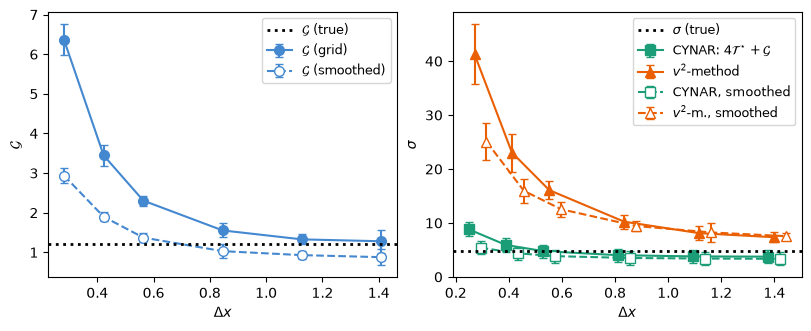

In [5]:
if d <= MAX_DIM_FOR_INFLOW:
    side0, R_arr, _ = inflow.propose_cell_sizes(X, N_TARGET_BINS_PER_DIM, R_LIST)
    print(f"Proposed base cell size side0={side0}, sweeping R={[float(r) for r in R_arr]}")

    cellsize_result = C.sweep_cellsize(X, dt, traffic_result["D_from_traffic"], side0, R_arr,
                                        traffic_result["slices"], n_min=N_MIN, thr_g=THR_G, Q=Q, w_min=W_MIN)
    g_star = C.pick_stable_G(cellsize_result)
    print(f"dx*={g_star['dx_star']:.4g}  G*={g_star['G_star_mean']:.4f} +/- {g_star['G_star_std']:.4f}")

    fig, axs = plt.subplots(1, 2, figsize=(8, 3.2), constrained_layout=True)
    C.plot_inflow_vs_cellsize_panel(axs[0], cellsize_result, true_values=true_values)
    C.plot_sigma_vs_cellsize_panel(axs[1], tr_star, cellsize_result, true_values=true_values)
    plt.show()
else:
    print(f"d={d} > MAX_DIM_FOR_INFLOW={MAX_DIM_FOR_INFLOW}: skipping the inflow/grid step. "
          f"Reporting a traffic-only estimate below.")
    cellsize_result, g_star, side0, R_arr = None, None, None, None

## 2D fields: density, velocity, and score

Only shown when the data is 2D, reconstructed at the cell size selected above.

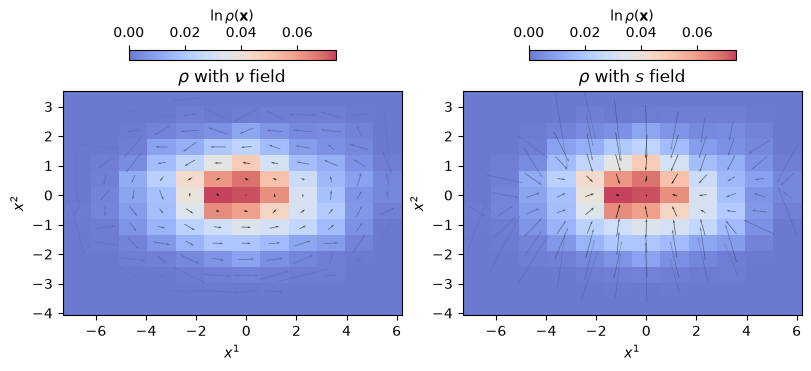

In [6]:
if d == 2 and g_star is not None:
    R_star = R_arr[g_star["idx"]]
    side_recon = R_star * side0
    D_recon = traffic_result["D_from_traffic"][0]
    icfg = cfg.InflowCfg(n_min=N_MIN, thr_g=THR_G, Q=Q)
    out_recon = inflow.grid_inflow(X, dt, side_recon, D_recon, cfg=icfg)
    edges, rho = out_recon["grid"]["edges"], out_recon["grid"]["rho"]
    nu, s = out_recon["grid"]["nu"], out_recon["grid"]["g"]

    fig, axs = plt.subplots(1, 2, figsize=(8, 3.6), constrained_layout=True)
    plot_field_rho(edges, rho, nu, ax=axs[0], obs=r"$\nu$")
    plot_field_rho(edges, rho, s, ax=axs[1], obs=r"$s$")
    plt.show()
else:
    print("2D field plots are only shown when d == 2 and the inflow step ran.")

## Summary

In [7]:
if g_star is not None:
    sigma_mean, sigma_std = C.combine_sigma_cynar(
        tr_star["Tr_star_mean"], tr_star["Tr_star_std"], g_star["G_star_mean"], g_star["G_star_std"])
    print(f"sigma_CYNAR = 4*Tr* + G* = {sigma_mean:.4f} +/- {sigma_std:.4f}")
else:
    sigma_mean, sigma_std = 4.0 * tr_star["Tr_star_mean"], 4.0 * tr_star["Tr_star_std"]
    print(f"Traffic-only estimate (inflow step skipped): 4*Tr* = {sigma_mean:.4f} +/- {sigma_std:.4f}")
    print("This is only the traffic contribution, not the complete sigma estimate.")

if true_values is not None and "sigma_true" in true_values:
    print(f"Reference sigma_true = {true_values['sigma_true']:.4f}")

sigma_CYNAR = 4*Tr* + G* = 3.8005 +/- 1.2154
Reference sigma_true = 4.8000
